<a href="https://colab.research.google.com/github/gaduhprakoso/PCVK_Ganjil2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Mengubah tingkat kecerahan citra 
------------------------------------
Masukkan nilai kecerahan: 30


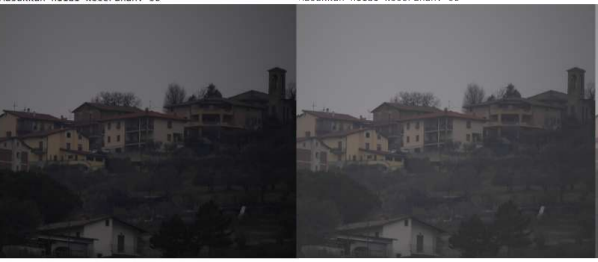

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    brightness = 0
    print('Error, masukkan angka yang valid.')

original = cv.imread('/content/houses.png')

if original is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path file Anda.")
else:
    brightness_image = np.zeros(original.shape, original.dtype)

    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                val = int(original[y, x, c]) + brightness
                brightness_image[y, x, c] = np.clip(val, 0, 255)

    final_frame = cv.hconcat([original, brightness_image])
    cv2_imshow(final_frame)

**TUGAS PRAKTIKUM**

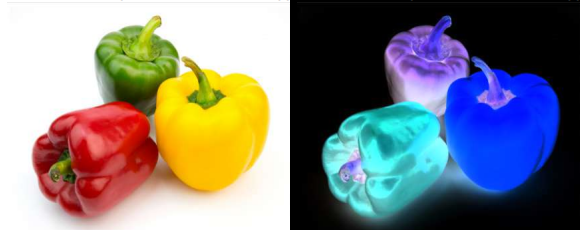

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

original = cv.imread('/content/paprika.png')

if original is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path file Anda.")
else:
    # Melakukan operasi inverse citra (negatif)
    inverse_image = 255 - original

    final_frame = cv.hconcat([original, inverse_image])
    cv2_imshow(final_frame)

 Mengubah kontras dan tingkat kecerahan citra 
--------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


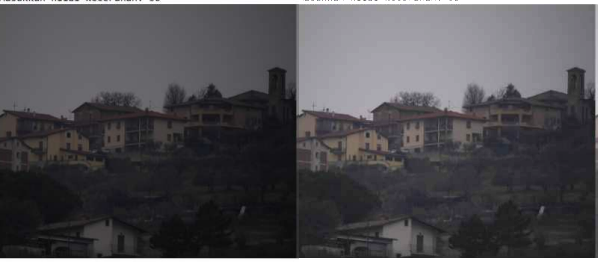

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah kontras dan tingkat kecerahan citra ')
print('--------------------------------------------')

try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    brightness = 0
    contrast = 1.0
    print('Input tidak valid, menggunakan nilai default.')

original = cv.imread('/content/houses.png')

if original is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path file Anda.")
else:
    # Menggunakan convertScaleAbs OpenCV untuk menerapkan kontras (alpha) dan kecerahan (beta)
    adjusted = cv.convertScaleAbs(original, alpha=contrast, beta=brightness)

    final_frame = cv.hconcat([original, adjusted])
    cv2_imshow(final_frame)

 Mengubah tingkat kecerahan citra dengan Transformasi Log 
---------------------------------------------------------
Masukkan nilai kecerahan: 30


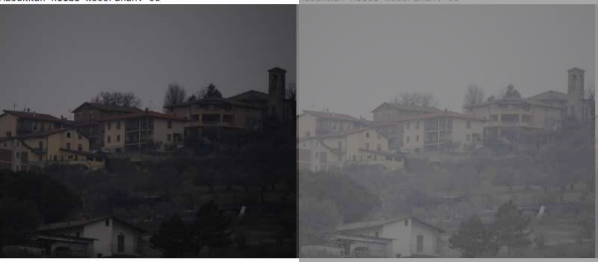

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra dengan Transformasi Log ')
print('---------------------------------------------------------')
try:
    c = float(input('Masukkan nilai kecerahan: '))
except ValueError:
    c = 50

Original = cv.imread('/content/houses.png')

if original is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path file Anda.")
else:
    gray_img = original.astype(np.float32)

    log_image = c * np.log(1 + gray_img)

    log_image = np.clip(log_image, 0, 255).astype(np.uint8)

    final_frame = cv.hconcat([original, log_image])
    cv2_imshow(final_frame)

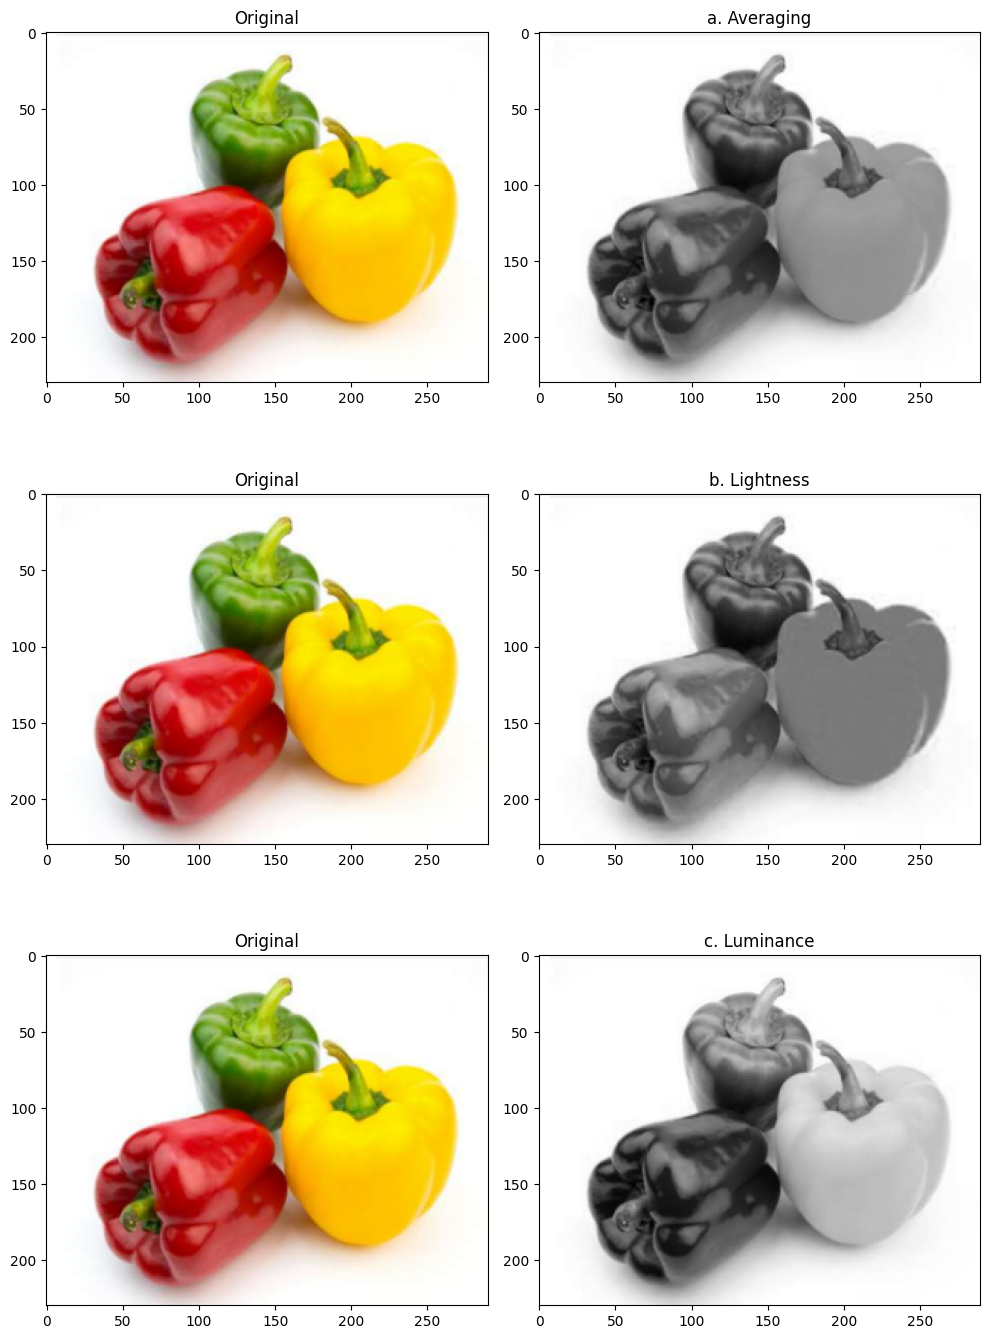

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/paprika.png')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

R = original_rgb[:, :, 0].astype(np.float32)
G = original_rgb[:, :, 1].astype(np.float32)
B = original_rgb[:, :, 2].astype(np.float32)

# a. Metode Averaging
gray_avg = np.clip((R + G + B) / 3, 0, 255).astype(np.uint8)

# b. Metode Lightness
max_rgb = np.maximum(np.maximum(R, G), B)
min_rgb = np.minimum(np.minimum(R, G), B)
gray_lightness = np.clip((max_rgb + min_rgb) / 2, 0, 255).astype(np.uint8)

# c. Metode Luminance (Luminosity)
gray_luminance = np.clip(0.21 * R + 0.72 * G + 0.07 * B, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(3, 2, figsize=(10, 14))

# Plot Averaging
axes[0, 0].imshow(original_rgb); axes[0, 0].set_title("Original")
axes[0, 1].imshow(gray_avg, cmap='gray'); axes[0, 1].set_title("a. Averaging")

# Plot Lightness
axes[1, 0].imshow(original_rgb); axes[1, 0].set_title("Original")
axes[1, 1].imshow(gray_lightness, cmap='gray'); axes[1, 1].set_title("b. Lightness")

# Plot Luminance
axes[2, 0].imshow(original_rgb); axes[2, 0].set_title("Original")
axes[2, 1].imshow(gray_luminance, cmap='gray'); axes[2, 1].set_title("c. Luminance")

plt.tight_layout()
plt.show()

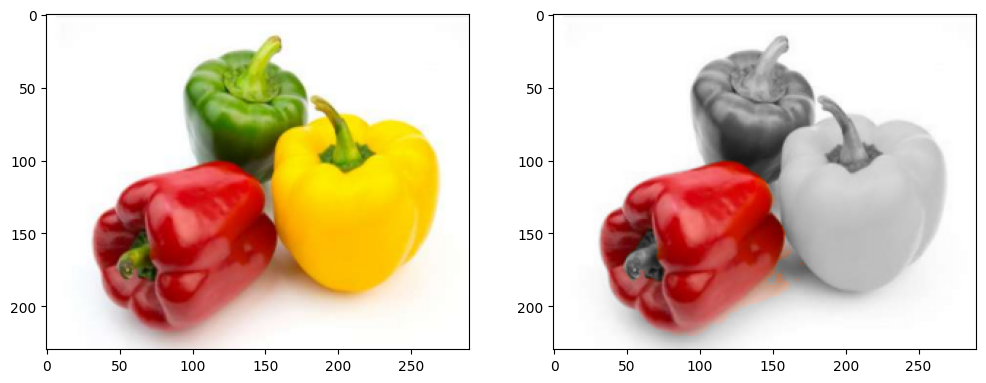

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/paprika.png')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
mask = mask1 | mask2

gray = cv.cvtColor(original_rgb, cv.COLOR_RGB2GRAY)
gray_rgb = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

result = gray_rgb.copy()

result[mask > 0] = original_rgb[mask > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_rgb)

axes[1].imshow(result)
plt.show()

 Gamma Correction pada citra 
---------------------------------
Masukkan nilai Gamma: 0.5


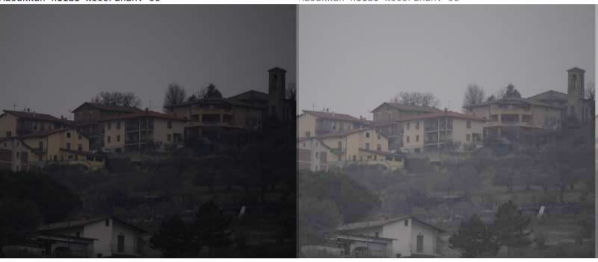

Berhasil menampilkan Gamma Correction dengan y = 0.5!


In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Gamma Correction pada citra ')
print('---------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    gamma = 1.0
    print('Error, not a number. Menggunakan nilai default gamma = 1.0')

original = cv.imread('/content/houses.png')

if original is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path file Anda.")
else:
    normalized = original.astype(np.float32) / 255.0

    gamma_corrected = np.power(normalized, gamma) * 255.0
    gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

    final_frame = cv.hconcat([original, gamma_corrected])
    cv2_imshow(final_frame)

 Simulasi Image Depth (Kuantisasi Citra) 
-------------------------------------------
Masukkan bit depth tujuan (1-8): 3
Bit depth awal : 8 bit
Bit depth tujuan : 3 bit
Jumlah level : 8


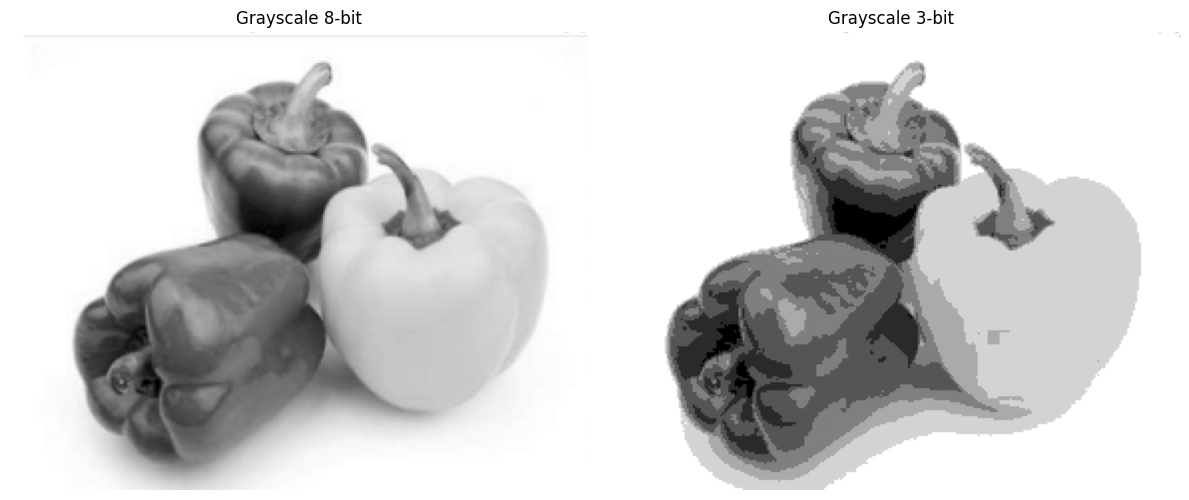

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Simulasi Image Depth (Kuantisasi Citra) ')
print('-------------------------------------------')

try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    bit_depth = 3
    print('Input tidak valid, menggunakan default bit_depth = 3')

level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/paprika.png', cv.IMREAD_GRAYSCALE)

if original is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path file Anda.")
else:
    depth_image = np.zeros(original.shape, original.dtype)

    depth_image = np.round((original / level)) * level
    depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)

    print(f'Bit depth awal : 8 bit')
    print(f'Bit depth tujuan : {bit_depth} bit')
    print(f'Jumlah level : {pow(2, bit_depth)}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("Grayscale 8-bit")
    axes[0].axis('off')

    axes[1].imshow(depth_image, cmap='gray')
    axes[1].set_title(f"Grayscale {bit_depth}-bit")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [34]:
import glob
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

original = cv.imread('/content/galaxy.png')

cv_img = []
for img in sorted(
    glob.glob('//content/drive/MyDrive/noises*.jpg')
):
  n = cv.imread(img)
  if n is not None:
    cv_img.append(n)

def hitung_psnr(img1, img2):
  mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
  if mse == 0:
    return 100.0
  max_pixel = 255.0
  psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
  return psnr


jumlah_citra_list = [10, 20, 40, 80, 100]

print('--- HASIL AVERAGE DENOISING & PSNR ---')
for jumlah in jumlah_citra_list:
  subset_img = cv_img[:jumlah]
  avg_image = np.mean(subset_img, axis=0).astype(np.uint8)
  nilai_psnr = hitung_psnr(original, avg_image)

  print(f'Jumlah Citra di-Average: {jumlah} | Nilai PSNR: {nilai_psnr:.2f} dB')


--- HASIL AVERAGE DENOISING & PSNR ---
Jumlah Citra di-Average: 10 | Nilai PSNR: 9.33 dB
Jumlah Citra di-Average: 20 | Nilai PSNR: 9.33 dB
Jumlah Citra di-Average: 40 | Nilai PSNR: 9.33 dB
Jumlah Citra di-Average: 80 | Nilai PSNR: 9.33 dB
Jumlah Citra di-Average: 100 | Nilai PSNR: 9.33 dB


/tmp/ipykernel_1503/3164758476.py:30: RuntimeWarning: invalid value encountered in cast
  avg_image = np.mean(subset_img, axis=0).astype(np.uint8)


1. Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Tidak selalu. Meskipun penambahan jumlah citra yang dirata-rata akan meningkatkan nilai PSNR dan meredam noise, kenaikan tersebut tidak bersifat linier selamanya. Peningkatan nilai PSNR sangat signifikan pada penambahan jumlah citra di awal, namun lambat laun peningkatannya akan semakin kecil (mengalami titik jenuh / diminishing returns).   

2. Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
Peningkatan kualitas dan nilai PSNR biasanya mulai melambat serta tidak terlalu signifikan setelah melewati rentang 40 hingga 80 citra. Penambahan jumlah citra dari 80 ke 100 hanya menghasilkan kenaikan nilai PSNR yang sangat kecil.

3. Apa Kesimpulan yang Anda peroleh dari percobaan ini?Operasi average denoising terbukti sangat efektif untuk mereduksi noise eksternal yang bersifat acak (seperti Gaussian noise).

* Operasi average denoising terbukti sangat efektif untuk mereduksi noise eksternal yang bersifat acak (seperti Gaussian noise).   
* Semakin banyak jumlah citra yang di-average, kualitas visual citra hasil akan semakin mendekati citra asli dan nilai PSNR (Peak Signal-to-Noise Ratio) akan semakin tinggi.   
* Namun, penentuan jumlah citra optimum harus mempertimbangkan efisiensi waktu komputasi, karena penambahan jumlah citra yang terlalu masif di atas batas tertentu tidak memberikan peningkatan hasil yang sebanding


Hasil Operator NOT:


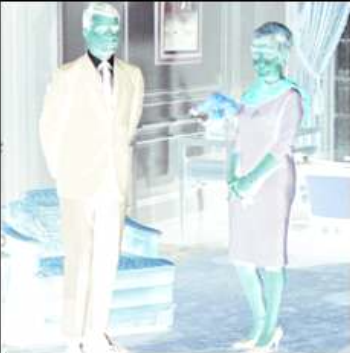

Hasil Operator OR:


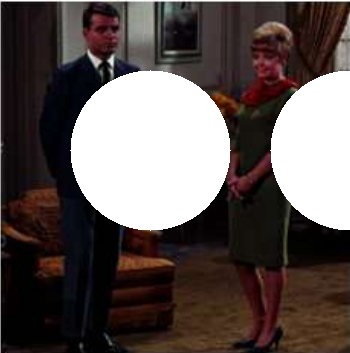

Hasil Operator AND:


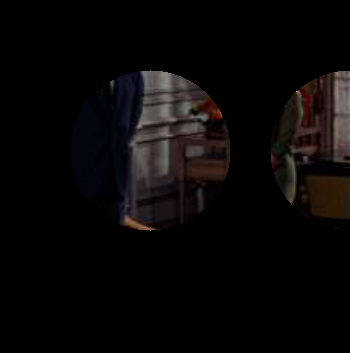

Hasil Operator NAND:


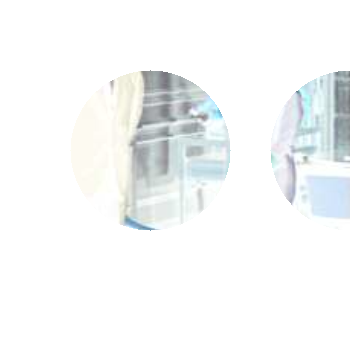

Hasil Operator XOR:


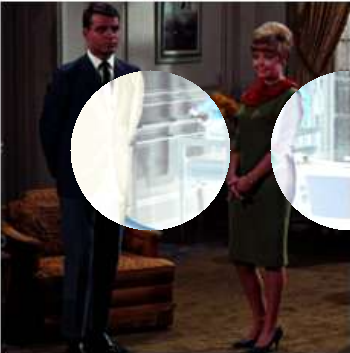

In [37]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

img = cv.imread('/content/couple.png')

mask = np.zeros(img.shape, dtype=np.uint8)
cv.circle(mask, (150, 150), 80, (255, 255, 255), -1)
cv.circle(mask, (350, 150), 80, (255, 255, 255), -1)

mask = cv.resize(mask, (img.shape[1], img.shape[0]))

op_not = cv.bitwise_not(img)          # NOT (Komplemen)
op_or = cv.bitwise_or(img, mask)      # OR
op_and = cv.bitwise_and(img, mask)    # AND (Masking standar)
op_nand = cv.bitwise_not(op_and)      # NAND (Not dari hasil AND)
op_xor = cv.bitwise_xor(img, mask)    # XOR

print("Hasil Operator NOT:")
cv2_imshow(op_not)
print("Hasil Operator OR:")
cv2_imshow(op_or)
print("Hasil Operator AND:")
cv2_imshow(op_and)
print("Hasil Operator NAND:")
cv2_imshow(op_nand)
print("Hasil Operator XOR:")
cv2_imshow(op_xor)

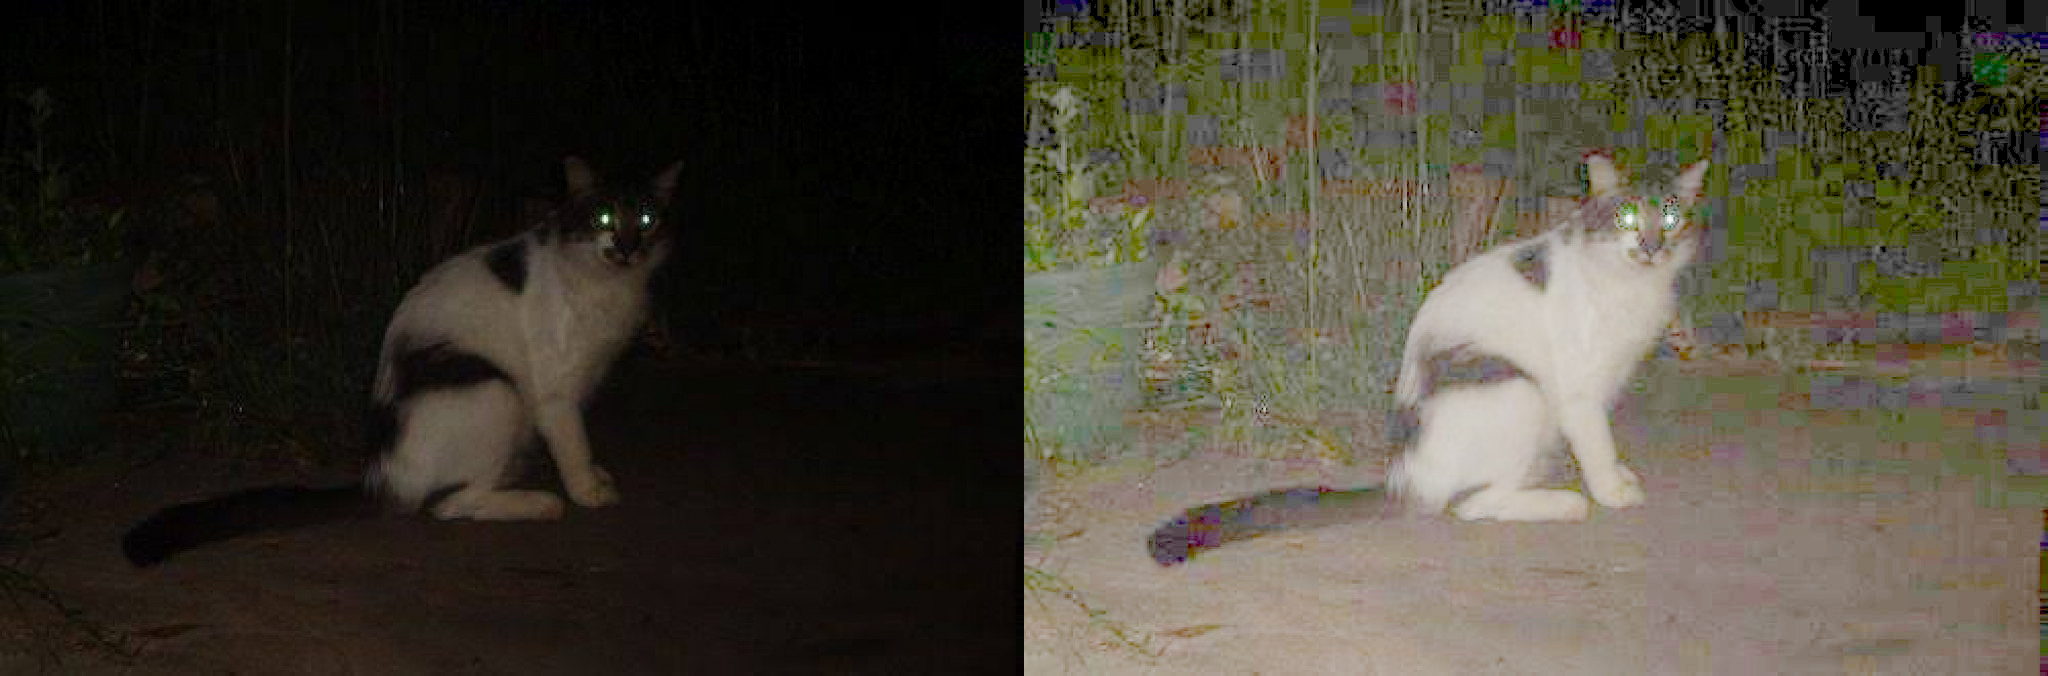

In [39]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

original = cv.imread('/content/cat.jpg')

if original is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path file Anda.")
else:
    gray_img = original.astype(np.float32)
    c = 45
    log_image = c * np.log(1 + gray_img)
    log_image = np.clip(log_image, 0, 255).astype(np.uint8)
    final_frame = cv.hconcat([original, log_image])
    cv2_imshow(final_frame)


alasan
* Berdasarkan ulasan teori modul, Transformasi Logaritma berfungsi untuk memetakan range input yang sempit dari nilai gray-level rendah (area gelap) ke dalam range yang lebih lebar pada output. Hal ini sangat efektif untuk mengangkat detail tersembunyi pada area gelap di foto malam hari tanpa membuat bagian yang sudah terang menjadi terlalu jenuh (oversaturated).   

resiko
* Peningkatan Noise: Karena metode ini menaikkan dan meregangkan intensitas piksel di area gelap, noise (bintik-bintik derau) yang biasanya tersembunyi di bagian gelap foto malam hari akan ikut terangkat dan menjadi lebih terlihat jelas.
* Penurunan Kontras Keseluruhan: Terkadang gambar bisa terlihat sedikit kabur atau kehilangan kedalaman kontras jika konstanta yang digunakan tidak disesuaikan dengan baik.

In [ ]:
original = cv.imread('/content/fish.png')

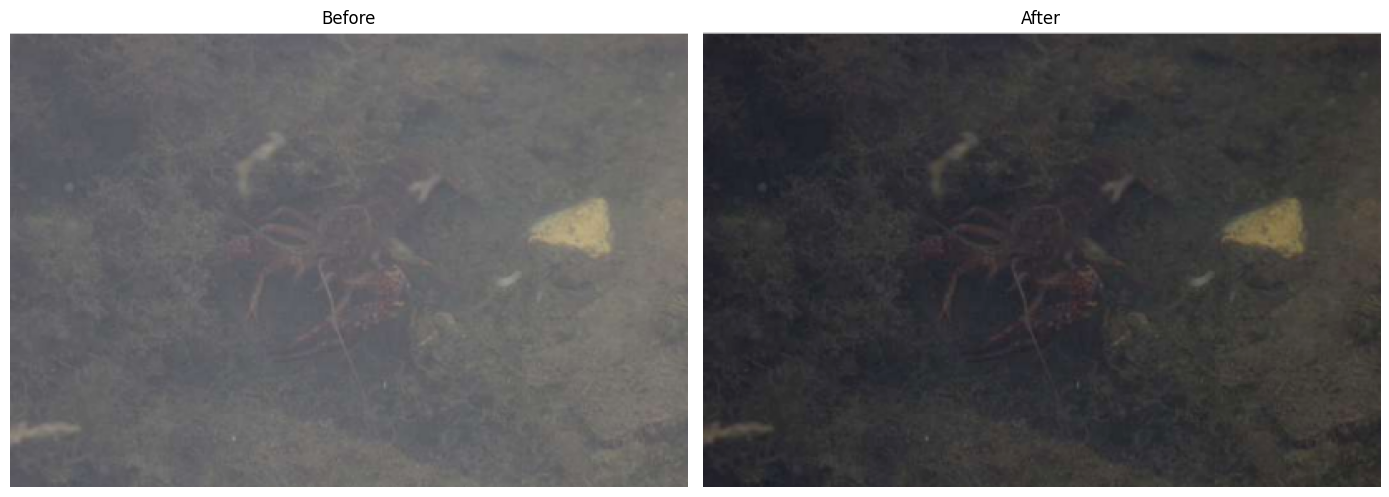

In [58]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/fish.png')

if original is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path file Anda.")
else:
    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    alpha = 1.1  # Tingkat kontras
    beta = -65   # Menyeimbangkan kecerahan agar detail udang lebih tajam/gelap natural

    adjusted = cv.convertScaleAbs(original, alpha=alpha, beta=beta)
    adjusted_rgb = cv.cvtColor(adjusted, cv.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(original_rgb)
    axes[0].set_title("Before")
    axes[0].axis('off')

    axes[1].imshow(adjusted_rgb)
    axes[1].set_title("After")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

1. Metode yang Dipilih

	Transformasi Linear Contrast & Brightness menggunakan fungsi cv.convertScaleAbs dari library OpenCV.
2. Alasan Pemilihan

	Citra asli memiliki masalah utama berupa kontras yang sangat rendah serta pencahayaan yang minim (under-exposed) akibat keruhnya lingkungan di dalam air, sehingga objek utama (udang karang) sulit dibedakan dengan latar belakangnya.
	Metode penyesuaian kontras dan kecerahan linier dipilih karena mampu meregangkan kembali rentang intensitas piksel secara proporsional. Dengan menaikkan sedikit kontras (α) dan menurunkan kecerahan (β), detail objek dapat ditajamkan sekaligus mengurangi efek kabur/pucat pada air keruh.
3. Penentuan Parameter Terbaik

	Berdasarkan uji coba iteratif pada citra tersebut, parameter terbaik yang menghasilkan visual paling seimbang dan tajam adalah:
	α (Kontras) = 1.1 (mempertegas batas atau tepi objek secara halus tanpa menimbulkan oversaturating).
	β (Kecerahan / Brightness) = -65 (memberikan nilai negatif untuk menggelapkan latar belakang keruh yang terlalu terang/pucat sehingga detail tekstur objek tampak lebih kontras dan natural).
